In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
RANDOM_STATE = 42

In [4]:
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='Class')

In [6]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: Class, Length: 178, dtype: int32

In [8]:
X.shape

(178, 13)

In [9]:
print(f"Dataset has {X.shape[0]} wines and {X.shape[1]} features")
print(f"Classes: {wine_data.target_names}")
print(f"Features: {list(X.columns)}")

Dataset has 178 wines and 13 features
Classes: ['class_0' 'class_1' 'class_2']
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [10]:
y.value_counts()

Class
1    71
0    59
2    48
Name: count, dtype: int64

In [11]:
print(X.isnull().sum().sum(), "missing values found")

0 missing values found


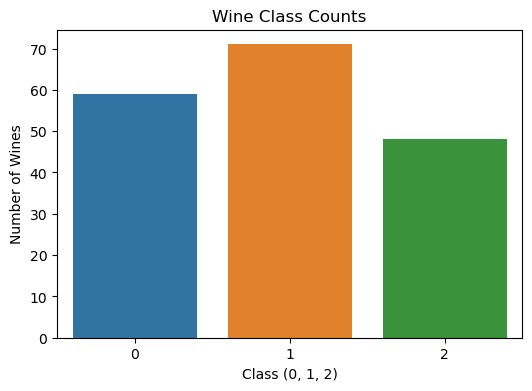

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Wine Class Counts')
plt.xlabel('Class (0, 1, 2)')
plt.ylabel('Number of Wines')
plt.savefig('class_distribution.png')
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [15]:
scaler = StandardScaler()

In [16]:
x_train_scale = scaler.fit_transform(X_train)

In [17]:
x_test_scaler= scaler.transform(X_test)

In [19]:
knn = KNeighborsClassifier()

In [20]:
knn.fit(x_train_scale,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
knn.score(x_test_scaler,y_test)

0.9722222222222222

In [23]:
k_range = range(1, 16)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train_scale, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

In [24]:
k_scores

[0.9366995073891626,
 0.9369458128078818,
 0.9440886699507389,
 0.9438423645320198,
 0.9509852216748769,
 0.951231527093596,
 0.9578817733990148,
 0.958128078817734,
 0.9507389162561577,
 0.9578817733990148,
 0.97192118226601,
 0.97192118226601,
 0.97192118226601,
 0.9578817733990148,
 0.9650246305418719]

In [25]:
optimal_k = k_range[np.argmax(k_scores)]
print(f"Best k: {optimal_k}")

Best k: 11


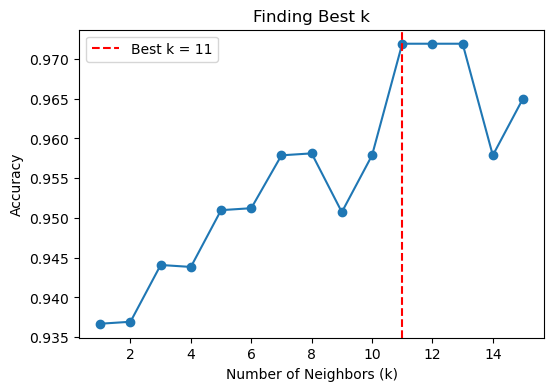

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, k_scores, marker='o')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Best k = {optimal_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Finding Best k')
plt.legend()
plt.show()

In [27]:
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(x_train_scale, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
y_test_pred = knn_model.predict(x_test_scaler)

In [29]:
pd.DataFrame({"y_true": y_test, "y_pred": y_test_pred})

,y_true,y_pred
10,0,0
134,2,2
28,0,0
121,1,1
62,1,1
51,0,0
7,0,0
66,1,1
129,1,1
166,2,2


In [30]:
def calculate_metrics(y_true, y_pred, name):
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.2f} ({accuracy*100:.1f}%)")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=wine_data.target_names))
    return {'accuracy': accuracy}

In [31]:
test_metrics = calculate_metrics(y_test, y_test_pred, "Testing")
test_metrics


Testing Results:
Accuracy: 1.00 (100.0%)
Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



{'accuracy': 1.0}

In [32]:
joblib.dump(knn_model, "knn.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
joblib.load("knn.pkl")
joblib.laod("scaler.pkl")

In [ ]:
age_group = [18-30, 31-45, 45-60]